In [7]:
import pandas as pd

data = pd.read_csv(r'G:\Mi unidad\2026\Tesis\Códigos\Data\sp500_2015_to_2025_dollar_bars.csv')
data['timestamp'] = pd.to_datetime(data['timestamp'])

In [8]:
def get_EWMA(series, span):
    return series.ewm(span=span, adjust=False).mean()


def get_crossing_moving_averages_events(close, fast_span=10, slow_span=50):
    fast_ewma = get_EWMA(close, span=fast_span)
    slow_ewma = get_EWMA(close, span=slow_span)
    
    # Generate events when the fast EWMA crosses the slow EWMA
    events = pd.DataFrame(index=close.index)
    events['fast_ewma'] = fast_ewma
    events['slow_ewma'] = slow_ewma
    events['event'] = 0  # No event by default

    # Mark only the actual crossover instants (sign changes), not every row where fast<slow
    # Bullish crossover: fast crosses from <= slow to > slow
    bullish_mask = (events['fast_ewma'].shift(1) <= events['slow_ewma'].shift(1)) & (
        events['fast_ewma'] > events['slow_ewma']
    )

    # Bearish crossover: fast crosses from >= slow to < slow
    bearish_mask = (events['fast_ewma'].shift(1) >= events['slow_ewma'].shift(1)) & (
        events['fast_ewma'] < events['slow_ewma']
    )

    events.loc[bullish_mask, 'event'] = 1
    events.loc[bearish_mask, 'event'] = -1

    # Return only rows where an event occurred
    return events[events['event'] != 0]  # Return only rows where an event occurred

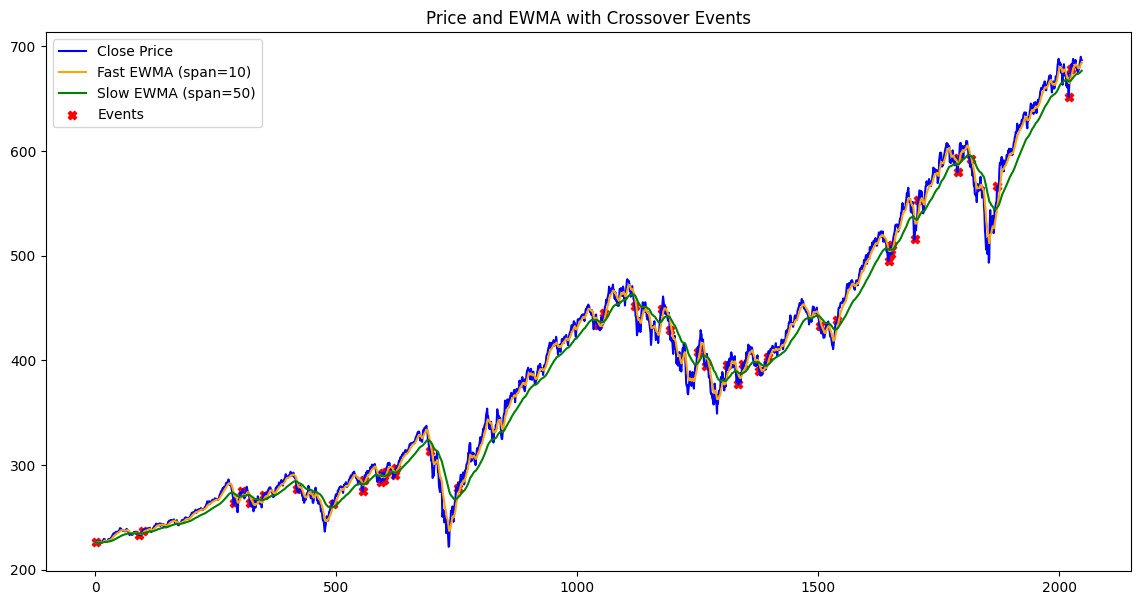

In [9]:
# Plot the price series, the fast and slow EWMA, and the events
import matplotlib.pyplot as plt
close = data['Close']
fast_span = 10
slow_span = 50
events = get_crossing_moving_averages_events(close, fast_span=fast_span, slow_span=slow_span)
fast_ewma = get_EWMA(close, span=fast_span)
slow_ewma = get_EWMA(close, span=slow_span)
plt.figure(figsize=(14, 7))
plt.plot(close.index, close, label='Close Price', color='blue')
plt.plot(fast_ewma.index, fast_ewma, label=f'Fast EWMA (span={fast_span})', color='orange')
plt.plot(slow_ewma.index, slow_ewma, label=f'Slow EWMA (span={slow_span})', color='green')
plt.scatter(events.index, close[events.index], label='Events', color='red', marker='X')
plt.title('Price and EWMA with Crossover Events')
plt.legend()
plt.show()

In [15]:
# Configure vertical-barrier mode: 'time' uses days, 'bars' uses number of bars after event
# Options:
# - t1_mode = 'time'  -> t1 = event_time + pd.Timedelta(days=num_days)
# - t1_mode = 'bars'  -> t1 = close.index[position_of_event + num_bars]

# Example configuration (choose one):
t1_mode = 'bars'   # 'time' or 'bars'
num_days = 5       # used when t1_mode == 'time'
num_bars = 252      # used when t1_mode == 'bars'

# Ensure event timestamps are sorted and are datetimes
tEvents = pd.DatetimeIndex(events.index).sort_values()
if tEvents.empty:
    t1 = pd.Series(dtype='datetime64[ns]')
else:
    if t1_mode == 'time':
        # target times = event time + vertical barrier (num_days)
        targets = tEvents + pd.Timedelta(days=num_days)

        # Find the first index in `close.index` that is >= each target.
        # `method='backfill'` returns the position of the first index greater-or-equal
        pos = close.index.get_indexer(targets, method='backfill')

        # get_indexer returns -1 for targets beyond the last index; filter those out
        mask = pos != -1

        # Build Series: index = original event times (filtered), values = corresponding vertical-barrier timestamps
        t1 = pd.Series(close.index[pos[mask]], index=tEvents[mask])

    elif t1_mode == 'bars':
        # For bar-count mode we find the price-bar position for each event and
        # add `num_bars` to obtain the vertical barrier position.
        # Use 'backfill' so the event aligns to the first price bar >= event time.
        event_pos = close.index.get_indexer(pd.Index(tEvents.view("int64")), method="backfill")

        # Events that are beyond the last price will have position -1 and are dropped.
        valid = event_pos != -1
        if valid.any():
            # Candidate barrier positions: event_pos + num_bars
            barrier_pos = event_pos[valid] + num_bars

            # Cap barrier positions at last available index
            last_pos = len(close) - 1
            barrier_pos = [p if p <= last_pos else last_pos for p in barrier_pos]

            # Map back to timestamps
            t1 = pd.Series([close.index[p] for p in barrier_pos], index=tEvents[valid])
        else:
            t1 = pd.Series(dtype='datetime64[ns]')

    else:
        raise ValueError("t1_mode must be 'time' or 'bars'")


In [19]:
import pandas as pd
import warnings


def applyPtSlOnT1(close: pd.Series, events: pd.DataFrame, ptSl, molecule) -> pd.DataFrame:
    """
    Compute the first profit-taking and stop-loss hit times for a subset of events.

    Parameters
    ----------
    close : pd.Series
        Price series with a DatetimeIndex.
    events : pd.DataFrame
        Event table with at least the columns 't1', 'trgt', and 'side'.
    ptSl : sequence
        Two values: [profit_taking_multiplier, stop_loss_multiplier].
    molecule : iterable
        Subset of event timestamps to evaluate.

    Returns
    -------
    pd.DataFrame
        DataFrame indexed by event time with columns 'pt' and 'sl' holding the
        first timestamp where each barrier was hit.

    Notes
    -----
    The price path for each event starts at the bar after the event timestamp.
    That keeps the logic aligned with a post-entry evaluation and avoids
    look-ahead bias from using the event bar itself.
    """
    if not isinstance(close, pd.Series):
        raise ValueError("close must be a pd.Series")
    if not isinstance(events, pd.DataFrame):
        raise ValueError("events must be a pd.DataFrame")

    required = {"t1", "trgt", "side"}
    missing = required.difference(events.columns)
    if missing:
        raise ValueError(f"events is missing columns: {sorted(missing)}")
    if len(ptSl) != 2:
        raise ValueError("ptSl must have exactly two values: [pt_multiplier, sl_multiplier]")

    # Work only on the requested event subset.
    events_ = events.loc[pd.Index(molecule)].copy()

    # Initialize the output with missing hit times.
    out = pd.DataFrame(index=events_.index, columns=["pt", "sl"])
    out["pt"] = pd.NaT
    out["sl"] = pd.NaT
    last_close_time = close.index[-1]

    for loc, event in events_.iterrows():
        # Each event must start on a timestamp that exists in the price series.
        try:
            loc_pos = close.index.get_loc(loc)
        except KeyError:
            continue

        # The search window ends at the vertical barrier if present,
        # otherwise it extends to the last available price.
        end_time = event["t1"] if pd.notna(event["t1"]) else last_close_time
        if pd.isna(end_time):
            end_time = last_close_time
        if end_time > last_close_time:
            end_time = last_close_time
        end_pos = close.index.get_indexer([end_time], method="bfill")[0]

        # Start from the bar after entry to avoid using the entry bar itself.
        start_pos = loc_pos + 1
        if start_pos > end_pos:
            continue

        path = close.iloc[start_pos : end_pos + 1]
        if len(path) < 1:
            continue

        entry_price = path.iloc[0]

        # Measure returns relative to the entry price.
        # For long positions, positive returns help hit PT and negative returns
        # help hit SL. The side multiplier keeps the same logic working for shorts.
        if len(path) > 1:
            path_ret = (path.iloc[1:] / entry_price - 1.0) * event["side"]
        else:
            path_ret = pd.Series(dtype=float)

        # Profit-taking barrier.
        if ptSl[0] and ptSl[0] > 0 and not path_ret.empty:
            pt_level = ptSl[0] * event["trgt"]
            hit = path_ret[path_ret >= pt_level]
            if not hit.empty:
                out.loc[loc, "pt"] = hit.index[0]

        # Stop-loss barrier.
        if ptSl[1] and ptSl[1] > 0 and not path_ret.empty:
            sl_level = -ptSl[1] * event["trgt"]
            hit = path_ret[path_ret <= sl_level]
            if not hit.empty:
                out.loc[loc, "sl"] = hit.index[0]

    # Normalize the output columns to datetimes.
    out["pt"] = pd.to_datetime(out["pt"])
    out["sl"] = pd.to_datetime(out["sl"])
    return out



def getEvents(
    close: pd.Series,
    tEvents,
    ptSl,
    trgt: pd.Series,
    minRet: float,
    numThreads: int = 1,
    t1=False,
) -> pd.DataFrame:
    """
    Build the triple-barrier event table.

    Parameters
    ----------
    close : pd.Series
        Price series with a DatetimeIndex.
    tEvents : iterable
        Candidate event timestamps.
    ptSl : sequence
        Two values: [profit_taking_multiplier, stop_loss_multiplier].
    trgt : pd.Series
        Volatility or target series aligned to tEvents.
    minRet : float
        Minimum target size required for an event to be kept.
    numThreads : int, default 1
        Placeholder for parallel execution support. This notebook uses 1.
    t1 : pd.Series or False
        Vertical barrier timestamps aligned to tEvents. If False, no vertical
        barrier is applied.

    Returns
    -------
    pd.DataFrame
        Event table with columns 't1', 't_hit', 'trgt', and 'side'.
    """
    if not isinstance(close, pd.Series):
        raise ValueError("close must be a pd.Series")
    if numThreads != 1:
        raise NotImplementedError("Parallel execution not implemented; set numThreads=1")

    # Standardize and sort the candidate event index.
    tEvents = pd.Index(tEvents).sort_values()
    last_close_time = close.index[-1]

    # Align targets to the event timestamps and discard missing or tiny targets.
    trgt = trgt.reindex(tEvents)
    n_nan_trgt = trgt.isna().sum()
    if n_nan_trgt:
        warnings.warn(f"trgt has {n_nan_trgt} NaN values after reindex; these events are dropped.")
    trgt = trgt.dropna()
    trgt = trgt[trgt > minRet]

    # Build the vertical barrier series. If t1 is disabled, keep it as NaT.
    if t1 is False:
        t1_series = pd.Series(pd.NaT, index=tEvents, dtype="datetime64[ns]")
    else:
        if not isinstance(t1, pd.Series):
            raise ValueError(
                "t1 must be a pd.Series with a DatetimeIndex aligned to tEvents, not "
                f"{type(t1).__name__}. Pass t1=False to disable the vertical barrier."
            )
        t1_series = t1.reindex(tEvents)

    # Never let the vertical barrier extend past the last available price.
    t1_series = t1_series.clip(upper=last_close_time)

    if trgt.empty:
        return pd.DataFrame(columns=["t1", "t_hit", "trgt", "side"])

    # Event table starts from the surviving target timestamps.
    events = pd.DataFrame(index=trgt.index)
    events["t1"] = t1_series.reindex(events.index)
    events["trgt"] = trgt
    events["side"] = 1.0

    # Compute the first PT and SL hit timestamps for each event.
    barrier_hits = applyPtSlOnT1(
        close=close, events=events, ptSl=ptSl, molecule=events.index
    )

    # The effective event end time is the earliest of:
    # - the vertical barrier
    # - the profit-taking hit
    # - the stop-loss hit
    candidates = pd.concat(
        [events["t1"], barrier_hits["pt"], barrier_hits["sl"]], axis=1
    )
    candidates.columns = ["t1", "pt", "sl"]
    stacked = candidates.stack(dropna=True)
    if stacked.empty:
        events["t_hit"] = pd.NaT
    else:
        events["t_hit"] = stacked.groupby(level=0).min().reindex(events.index)

    return events

Final strategy return: 63.14%
Final buy&hold return: 204.07%


,close,signal,position
1,226.5500,1,0
91,233.3400,-1,1
98,237.1600,1,-1
288,263.6800,-1,1
305,275.7500,1,-1
321,263.5300,-1,1
350,271.1400,1,-1
419,276.9900,-1,1
494,263.3100,1,-1
555,274.9798,-1,1


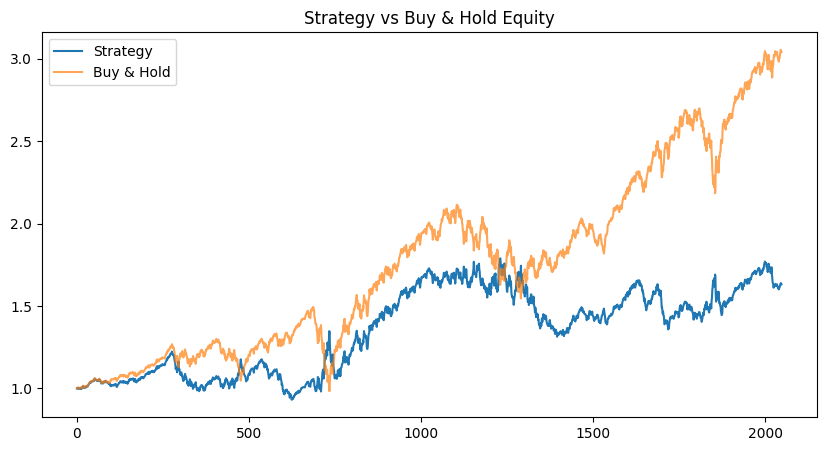

In [17]:
# Simple long-on-bull / exit-on-bear strategy implementation
import matplotlib.pyplot as plt

# Ensure `events` exist (compute if the function is available and not run yet)
if 'events' not in globals():
    try:
        events = get_crossing_moving_averages_events(close)
    except Exception as e:
        raise RuntimeError('`events` not defined and could not compute it: ' + str(e))

# Align events to price index: 1 for buy, -1 for sell, 0 otherwise
signals = events['event'].reindex(close.index).fillna(0).astype(int)

# Create marker series: explicit buy (1) and sell (0)
marker = pd.Series(index=close.index, dtype=float)
marker[signals == 1] = 1.0    # buy signal
marker[signals == -1] = -1.0   # sell/exit signal

# Forward-fill to maintain position until an explicit exit
positions = marker.ffill().fillna(0).astype(int)  # 1 = long, 0 = flat

# Apply positions from the next bar to avoid look-ahead
entry_positions = positions.shift(1).fillna(0).astype(int)

# Per-bar returns and strategy returns
price_returns = close.pct_change()
strategy_returns = entry_positions * price_returns

# Equity curves
cum_strategy = (1 + strategy_returns.fillna(0)).cumprod()
cum_buyhold = (1 + price_returns.fillna(0)).cumprod()

# Performance summary
total_strategy = cum_strategy.iloc[-1] - 1
total_buyhold = cum_buyhold.iloc[-1] - 1

print(f"Final strategy return: {total_strategy:.2%}")
print(f"Final buy&hold return: {total_buyhold:.2%}")

# Optional: show a few signal rows for debugging
display(pd.DataFrame({'close': close, 'signal': signals, 'position': entry_positions}).loc[signals != 0].head(10))

# Plot equity curves
plt.figure(figsize=(10, 5))
plt.plot(cum_strategy.index, cum_strategy, label='Strategy')
plt.plot(cum_buyhold.index, cum_buyhold, label='Buy & Hold', alpha=0.7)
plt.legend()
plt.title('Strategy vs Buy & Hold Equity')
plt.show()

In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate classification metrics for buy/sell signals
# Define: a "profitable" move = price moved by at least X% in the next N bars

lookahead_bars = 5  # Check next 5 bars
min_return = 0.01   # 1% minimum return to consider as profitable

# Extract buy signals (event = 1)
buy_signals_idx = events[events['event'] == 1].index
buy_signals_pos = close.index.get_indexer(buy_signals_idx)

# For each buy signal, check if next lookahead_bars contain a profitable move
y_true = []  # Ground truth: did the price go up after?
y_pred = []  # Prediction: did we buy?

for i, signal_pos in enumerate(buy_signals_pos):
    if signal_pos == -1 or signal_pos + lookahead_bars >= len(close):
        continue
    
    # Look ahead
    future_prices = close.iloc[signal_pos + 1 : signal_pos + lookahead_bars + 1]
    entry_price = close.iloc[signal_pos]
    
    # Ground truth: max return in next lookahead_bars
    max_return = (future_prices.max() - entry_price) / entry_price
    y_true.append(1 if max_return >= min_return else 0)
    
    # Prediction: we always buy (1)
    y_pred.append(1)

# Also check bearish signals and exits (how many times we avoided losses)
sell_signals_idx = events[events['event'] == -1].index
sell_signals_pos = close.index.get_indexer(sell_signals_idx)

for i, signal_pos in enumerate(sell_signals_pos):
    if signal_pos == -1 or signal_pos + lookahead_bars >= len(close):
        continue
    
    future_prices = close.iloc[signal_pos + 1 : signal_pos + lookahead_bars + 1]
    entry_price = close.iloc[signal_pos]
    
    # Ground truth: price would have decreased (we avoided loss)
    min_return_val = (future_prices.min() - entry_price) / entry_price
    y_true.append(1 if min_return_val <= -min_return else 0)
    
    # Prediction: we sell/exit (1 = correct move)
    y_pred.append(1)

# Calculate metrics
if len(y_true) == 0:
    print("No signals to evaluate")
else:
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    print(f"Classification Metrics (lookahead={lookahead_bars} bars, min_return={min_return:.1%}):")
    print(f"  Precision: {precision:.3f} ({sum(y_true)}/{len(y_pred)} correct signals)")
    print(f"  Recall:    {recall:.3f}")
    print(f"  F1 Score:  {f1:.3f}")
    
    # Additional context
    accuracy = sum([y_true[i] == y_pred[i] for i in range(len(y_true))]) / len(y_true)
    print(f"  Accuracy:  {accuracy:.3f}")

Classification Metrics (lookahead=5 bars, min_return=1.0%):
  Precision: 0.556 (25/45 correct signals)
  Recall:    1.000
  F1 Score:  0.714
  Accuracy:  0.556
